# 4-Level Hierarchical Multi-Agent Organization (LangGraph)

```
LEVEL 1   CEO / TOP SUPERVISOR AGENT
                  ↓  decides which division handles the task
          ┌───────────────┴───────────────┐
          ↓                               ↓
LEVEL 2   ENGINEERING DIRECTOR            OPERATIONS DIRECTOR
          (chooses teams)                 (chooses teams)
          ┌──────┼──────┐                 ┌──────┼──────┐
          ↓      ↓      ↓                 ↓      ↓      ↓
LEVEL 3   Database Backend Frontend       QA     DevOps Security
          Team     Team    Team           Team   Team   Team
          Supervisor ...                  Supervisor ...
              ↓                               ↓
LEVEL 4   3 specialist agents per team  (18 specialists in total)
```

| Division | Team | Specialist agents |
|---|---|---|
| Engineering | Database | SQL · Schema · Query Optimization |
| Engineering | Backend | API · Auth · Microservice |
| Engineering | Frontend | React · UI · Accessibility |
| Operations | QA | Unit Test · Integration Test · Regression |
| Operations | DevOps | Docker · Kubernetes · CI/CD |
| Operations | Security | Vulnerability · IAM · Secrets |

**How it runs**
- Every level above the specialists is an **LLM decision**: CEO → divisions, Director → teams, Team supervisor → specialists. Invalid or empty answers fall back to "use everyone".
- **Specialists (level 4)** run **in parallel** inside a team (fan-out → writer fan-in).
- **Engineering teams run sequentially** (database → backend → frontend: each builds on the previous one). **Operations teams run in parallel** (QA, DevOps, Security are independent).
- **Divisions run sequentially** (Engineering first, then Operations reviews its report), then a final answer is written.
- Each team and each division is its **own compiled graph**; one **config dict (`ORG`)** describes the whole company, and builder functions generate the graphs, so nothing is copy-pasted 18 times.

> ⚠️ A run that selects everything makes ~36 LLM calls. On a free-tier model this can hit rate limits - start with a narrow task (see the last cell).

**Reference docs:** [graph API & parallel branches](https://langchain-ai.github.io/langgraph/how-tos/graph-api/) · [subgraphs](https://langchain-ai.github.io/langgraph/concepts/subgraphs/) · [state & reducers](https://langchain-ai.github.io/langgraph/concepts/low_level/) · [multi-agent concepts](https://langchain-ai.github.io/langgraph/concepts/multi_agent/)

## 1. Imports & model

In [1]:
import json
import operator
import os
import re
from typing import Annotated, TypedDict

from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage

from langgraph.graph import END, START, StateGraph, add_messages
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [2]:
api_key = os.getenv("OPENROUTER_API_KEY") or os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Set OPENROUTER_API_KEY (or OPENAI_API_KEY) in your .env file.")

model = ChatOpenAI(
    model="nvidia/nemotron-3-ultra-550b-a55b:free",
    temperature=0,
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1",
    max_retries=3,   # free models hit 429 rate limits often
    timeout=120,
)

## 2. Helpers

`llm_choose` is the one decision function used by **every** supervisor level: it shows the options, asks for JSON, validates the answer and falls back to *all options* if the model misbehaves.

In [3]:
def reply_text(response, fallback="(no output)"):
    """Reply as a NON-EMPTY string (an empty one could make downstream logic misbehave)."""
    content = response.content
    if isinstance(content, list):
        content = "".join(b.get("text", "") if isinstance(b, dict) else str(b) for b in content)
    return (content or "").strip() or fallback


def parse_json_reply(response, default: dict) -> dict:
    """Extract the first {...} object from a reply (handles ```json fences / extra prose)."""
    match = re.search(r"\{.*\}", reply_text(response, ""), re.DOTALL)
    if match:
        try:
            data = json.loads(match.group(0))
            if isinstance(data, dict):
                return data
        except json.JSONDecodeError:
            pass
    return default


def llm_choose(role: str, task: str, context: str, options: dict, noun: str):
    """Ask the LLM (acting as `role`) to pick from `options`. Returns (chosen_keys, reason)."""
    menu = "\n".join(f"- {key}: {desc}" for key, desc in options.items())
    ctx = f"\nContext from earlier work:\n{context}\n" if context else ""
    prompt = f"""You are the {role}. Task: {task}
{ctx}
Choose which {noun} are needed. Options:
{menu}

Reply ONLY with JSON: {{"choices": ["option_key"], "reason": "one sentence"}}"""
    data = parse_json_reply(model.invoke([HumanMessage(content=prompt)]), {})
    chosen = [k for k in options if k in data.get("choices", [])] or list(options)  # keep config order
    reason = str(data.get("reason", ""))
    print(f"[{role}] -> {chosen}")
    return chosen, reason

## 3. The organization (one config describes all 4 levels)

Dict order matters: it is the **execution order** for sequential levels (database → backend → frontend; engineering → operations).

In [4]:
ORG = {
    "engineering": {
        "title": "Engineering Director",
        "focus": "builds the feature: database, backend services and frontend UI",
        "mode": "sequential",          # teams build on each other: schema -> API -> UI
        "teams": {
            "database": {
                "title": "Database Team Supervisor",
                "focus": "schemas, SQL and query performance",
                "agents": {
                    "sql": "SQL Agent: writes the SQL (DDL/DML, seed data, integrity constraints)",
                    "schema": "Schema Agent: designs tables, relations and migrations",
                    "query_optimization": "Query Optimization Agent: indexes, query plans, performance",
                },
            },
            "backend": {
                "title": "Backend Team Supervisor",
                "focus": "APIs, authentication and services",
                "agents": {
                    "api": "API Agent: designs and implements routes, validation, integration",
                    "auth": "Auth Agent: authentication, sessions/tokens, authorization",
                    "microservice": "Microservice Agent: service boundaries, messaging, deployment shape",
                },
            },
            "frontend": {
                "title": "Frontend Team Supervisor",
                "focus": "user interface and accessibility",
                "agents": {
                    "react": "React Agent: components, state management, routing",
                    "ui": "UI Agent: layout, styling, design system, responsiveness",
                    "accessibility": "Accessibility Agent: WCAG, keyboard/screen-reader support",
                },
            },
        },
    },
    "operations": {
        "title": "Operations Director",
        "focus": "verifies and ships the work: testing, infrastructure/CI-CD and security",
        "mode": "parallel",            # QA, DevOps, Security are independent reviews
        "teams": {
            "qa": {
                "title": "QA Team Supervisor",
                "focus": "unit, integration and regression testing",
                "agents": {
                    "unit_test": "Unit Test Agent: unit test cases, coverage",
                    "integration_test": "Integration Test Agent: cross-component and API tests",
                    "regression": "Regression Agent: regression suites, release checks",
                },
            },
            "devops": {
                "title": "DevOps Team Supervisor",
                "focus": "containers, Kubernetes and CI/CD pipelines",
                "agents": {
                    "docker": "Docker Agent: images, compose, build optimization",
                    "kubernetes": "Kubernetes Agent: manifests, scaling, rollout strategy",
                    "cicd": "CI/CD Agent: pipelines, quality gates, deployment automation",
                },
            },
            "security": {
                "title": "Security Team Supervisor",
                "focus": "vulnerabilities, access control and secrets",
                "agents": {
                    "vulnerability": "Vulnerability Agent: SAST/DAST findings, dependency CVEs",
                    "iam": "IAM Agent: roles, least privilege, access policies",
                    "secrets": "Secrets Agent: secret storage, rotation, leak prevention",
                },
            },
        },
    },
}
DIVISIONS = list(ORG)
print(f"{len(ORG)} divisions, {sum(len(d['teams']) for d in ORG.values())} teams, "
      f"{sum(len(t['agents']) for d in ORG.values() for t in d['teams'].values())} specialist agents")

2 divisions, 6 teams, 18 specialist agents


## 4. Levels 3 & 4 - team graph (supervisor + 3 specialists in parallel)

`supervisor → (specialist_a | specialist_b | specialist_c) → writer`

- The team supervisor picks the needed specialists; unpicked ones return `{}` and skip.
- `agent_outputs` uses the `operator.or_` **reducer** so parallel branches can write to it in the same step.
- The writer waits for all branches: `add_edge([...], "writer")`.

In [5]:
class TeamGraphState(TypedDict):
    task: str
    context: str                                   # work from earlier teams/divisions
    chosen: list[str]
    reason: str
    agent_outputs: Annotated[dict, operator.or_]   # reducer = safe parallel writes
    team_output: str


def make_team_graph(team_cfg: dict):
    agents = team_cfg["agents"]
    title = team_cfg["title"]

    def supervisor(state: TeamGraphState):
        chosen, reason = llm_choose(title, state["task"], state.get("context", ""), agents, "specialist agents")
        return {"chosen": chosen, "reason": reason}

    def make_agent(name: str, role: str):
        def run_agent(state: TeamGraphState):
            if name not in state["chosen"]:
                return {}                           # not selected -> skip
            ctx = f"\n\nContext from earlier work:\n{state['context']}" if state.get("context") else ""
            prompt = (f"You are the {role}.\nTask: {state['task']}{ctx}\n\n"
                      f"Supervisor's reasoning: {state.get('reason', '')}\n"
                      "Give your concrete contribution from your specialty only. Be concise.")
            return {"agent_outputs": {name: reply_text(model.invoke([HumanMessage(content=prompt)]))}}
        return run_agent

    def writer(state: TeamGraphState):
        combined = "\n\n".join(f"{k.upper()}:\n{v}" for k, v in state.get("agent_outputs", {}).items())
        prompt = f"You are the {title}. Combine these specialist outputs into one concise team report:\n\n{combined}"
        return {"team_output": reply_text(model.invoke([HumanMessage(content=prompt)]))}

    g = StateGraph(TeamGraphState)
    g.add_node("supervisor", supervisor)
    for name, role in agents.items():
        g.add_node(f"{name}_agent", make_agent(name, role))
    g.add_node("writer", writer)

    g.add_edge(START, "supervisor")
    for name in agents:                                             # fan-out
        g.add_edge("supervisor", f"{name}_agent")
    g.add_edge([f"{n}_agent" for n in agents], "writer")            # fan-in (waits for all)
    g.add_edge("writer", END)
    return g.compile()


team_graphs = {
    div_key: {team_key: make_team_graph(team_cfg) for team_key, team_cfg in div_cfg["teams"].items()}
    for div_key, div_cfg in ORG.items()
}
print("team graphs:", {d: list(t) for d, t in team_graphs.items()})

team graphs: {'engineering': ['database', 'backend', 'frontend'], 'operations': ['qa', 'devops', 'security']}


## 5. Level 2 - division graph (director + 3 team graphs)

`director → teams → writer`. The same builder produces both directors; `mode` decides the edge shape:
- **sequential** (Engineering): `director → database → backend → frontend → writer`, and each team receives the earlier teams' reports.
- **parallel** (Operations): the director fans out to all teams and the writer waits for all of them.

In [6]:
class DivisionGraphState(TypedDict):
    task: str
    context: str
    chosen: list[str]
    reason: str
    team_outputs: Annotated[dict, operator.or_]
    division_output: str


def make_division_graph(div_key: str, div_cfg: dict):
    teams = div_cfg["teams"]
    title = div_cfg["title"]
    sequential = div_cfg["mode"] == "sequential"

    def director(state: DivisionGraphState):
        options = {k: v["focus"] for k, v in teams.items()}
        chosen, reason = llm_choose(title, state["task"], state.get("context", ""), options, "teams")
        return {"chosen": chosen, "reason": reason}

    def make_team_node(team_key: str):
        def run_team(state: DivisionGraphState):
            if team_key not in state["chosen"]:
                return {}
            context = state.get("context", "")
            if sequential and state.get("team_outputs"):               # build on earlier teams
                earlier = "\n\n".join(f"{k.upper()} TEAM REPORT:\n{v}" for k, v in state["team_outputs"].items())
                context = f"{context}\n\n{earlier}".strip()
            out = team_graphs[div_key][team_key].invoke({"task": state["task"], "context": context})
            return {"team_outputs": {team_key: out["team_output"]}}
        return run_team

    def writer(state: DivisionGraphState):
        combined = "\n\n".join(f"{k.upper()} TEAM:\n{v}" for k, v in state.get("team_outputs", {}).items())
        prompt = f"You are the {title}. Combine these team reports into one concise division report:\n\n{combined}"
        return {"division_output": reply_text(model.invoke([HumanMessage(content=prompt)]))}

    g = StateGraph(DivisionGraphState)
    g.add_node("director", director)
    for team_key in teams:
        g.add_node(f"{team_key}_team", make_team_node(team_key))
    g.add_node("writer", writer)

    g.add_edge(START, "director")
    team_nodes = [f"{t}_team" for t in teams]
    if sequential:                                                     # one chain
        chain = ["director"] + team_nodes + ["writer"]
        for a, b in zip(chain, chain[1:]):
            g.add_edge(a, b)
    else:                                                              # fan-out / fan-in
        for node in team_nodes:
            g.add_edge("director", node)
        g.add_edge(team_nodes, "writer")
    g.add_edge("writer", END)
    return g.compile()


division_graphs = {div_key: make_division_graph(div_key, div_cfg) for div_key, div_cfg in ORG.items()}
print({k: ORG[k]["mode"] for k in ORG})

{'engineering': 'sequential', 'operations': 'parallel'}


## 6. Level 1 - CEO graph (top supervisor → divisions → final answer)

In [7]:
class OrgState(TypedDict):
    task: str
    divisions: list[str]                                   # chosen by the CEO
    reason: str
    division_outputs: Annotated[dict, operator.or_]
    final_answer: str
    message: Annotated[list, add_messages]


def ceo(state: OrgState):
    """Level 1: decides which division(s) should handle the task."""
    options = {k: v["focus"] for k, v in ORG.items()}
    chosen, reason = llm_choose("CEO / Top Supervisor", state["task"], "", options, "divisions")
    return {"divisions": chosen, "reason": reason}


def make_division_node(div_key: str):
    def run_division(state: OrgState):
        context = "\n\n".join(f"{k.upper()} DIVISION REPORT:\n{v}" for k, v in state.get("division_outputs", {}).items())
        out = division_graphs[div_key].invoke({"task": state["task"], "context": context})
        report = out["division_output"]
        return {
            "division_outputs": {div_key: report},
            "message": [AIMessage(content=report, name=f"{div_key}_division")],
        }
    return run_division


def final(state: OrgState):
    """Merge the division reports into one answer."""
    parts = "\n\n".join(f"{k.upper()} DIVISION REPORT:\n{v}" for k, v in state.get("division_outputs", {}).items())
    prompt = f"""You are the CEO. Task: {state['task']}

Write one concise final answer for the user from these division reports:

{parts}"""
    answer = reply_text(model.invoke([HumanMessage(content=prompt)]))
    return {"final_answer": answer, "message": [AIMessage(content=answer, name="ceo")]}


def route_after(current):
    """Router: next CHOSEN division after `current` (None = right after the CEO), else 'final'."""
    def router(state: OrgState):
        start = 0 if current is None else DIVISIONS.index(current) + 1
        for d in DIVISIONS[start:]:
            if d in state["divisions"]:
                return f"{d}_division"
        return "final"
    return router


builder = StateGraph(OrgState)
builder.add_node("ceo", ceo)
for d in DIVISIONS:
    builder.add_node(f"{d}_division", make_division_node(d))
builder.add_node("final", final)

builder.add_edge(START, "ceo")
builder.add_conditional_edges("ceo", route_after(None), [f"{d}_division" for d in DIVISIONS])
for i, d in enumerate(DIVISIONS):
    later = [f"{x}_division" for x in DIVISIONS[i + 1:]] + ["final"]
    builder.add_conditional_edges(f"{d}_division", route_after(d), later)
builder.add_edge("final", END)

graph = builder.compile(checkpointer=InMemorySaver())
print("Org graph compiled successfully!")

Org graph compiled successfully!


## 7. Visualize: top graph, one division (sequential), one division (parallel), one team

TOP (CEO) GRAPH


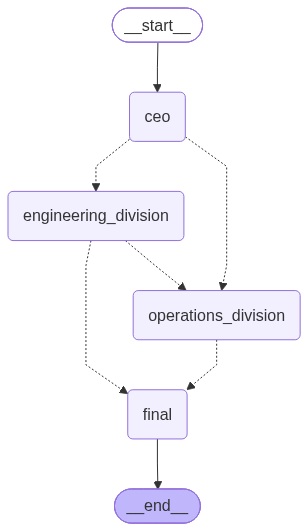

ENGINEERING DIVISION (sequential teams)


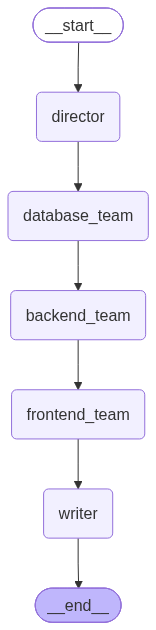

OPERATIONS DIVISION (parallel teams)


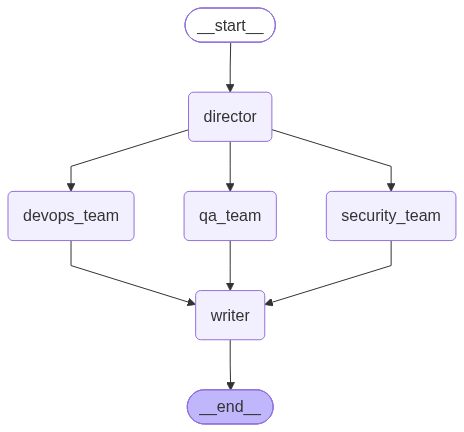

FRONTEND TEAM (parallel specialists)


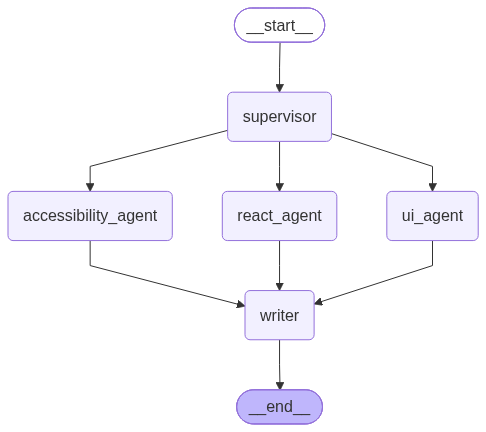

In [8]:
from IPython.display import Image, display

views = [
    ("TOP (CEO) GRAPH", graph),
    ("ENGINEERING DIVISION (sequential teams)", division_graphs["engineering"]),
    ("OPERATIONS DIVISION (parallel teams)", division_graphs["operations"]),
    ("FRONTEND TEAM (parallel specialists)", team_graphs["engineering"]["frontend"]),
]
for title, g in views:
    print(title)
    try:
        display(Image(g.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Could not display PNG ({e}). Mermaid source:\n")
        print(g.get_graph().draw_mermaid())

## 8. Run it

The printed `[role] -> [...]` lines show every decision at every level, top to bottom.

In [9]:
# A narrow task keeps the call count low (good for free-tier rate limits).
task = "Add a 'forgot password' flow: only the backend auth API and its security review are needed."

# For the full end-to-end run (~36 LLM calls) use e.g.:
# task = "Build a user authentication system with login, registration, and password reset, then test, secure and ship it."

initial_state = {"task": task, "divisions": [], "reason": "", "division_outputs": {}, "final_answer": "", "message": []}
config = {"configurable": {"thread_id": "org-1"}, "recursion_limit": 25}

for step in graph.stream(initial_state, config=config, stream_mode="updates"):
    for node in step:
        print(f"==> level-1 node finished: {node}")

result = graph.get_state(config).values
for div, report in result["division_outputs"].items():
    print("\n" + "=" * 60 + f"\n{div.upper()} DIVISION REPORT\n" + "=" * 60)
    print(report)
print("\n" + "=" * 60 + "\nFINAL ANSWER\n" + "=" * 60)
print(result["final_answer"])

[CEO / Top Supervisor] -> ['engineering', 'operations']
==> level-1 node finished: ceo
[Engineering Director] -> ['backend']


ValueError: {'message': 'Upstream error from Nvidia: Service temporarily overloaded', 'code': 503, 'metadata': {'error_type': 'provider_overloaded'}}

## 9. Where to go next

- Give specialists real **tools** (`create_react_agent` from `langgraph.prebuilt`) instead of single LLM calls: https://langchain-ai.github.io/langgraph/agents/agents/
- Add **human approval** before the DevOps/Kubernetes agents act: https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/
- Switch `mode` in `ORG` to try engineering in parallel or operations in sequence - only the edges change.
- Trace the 4 levels with LangSmith: https://docs.smith.langchain.com/